# Titanic Survival Prediction 🚢

This project aims to predict whether a passenger survived the Titanic disaster using Machine Learning.

## Project Workflow

1. Data Loading
2. Exploratory Data Analysis
3. Data Preprocessing
4. Machine Learning Model Training
5. Hyperparameter Tuning
6. Model Evaluation
7. Best Model Selection

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent / "src"))

from Data_Preprocessing import read_data, preprocess, separate_target
from EDA import eda

## 1. Data Loading

The Titanic dataset is loaded using the `read_data()` function from the preprocessing module.

In [2]:
df = read_data()

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Dataset Overview

In [3]:
print("Dataset Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (891, 12)

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


## 2. Exploratory Data Analysis

The EDA phase is performed using the `eda()` function.

It includes:

- Dataset shape
- Data types
- Descriptive statistics
- Missing value visualization
- Age distribution
- Outlier detection
- Correlation analysis
- Survival analysis by categorical features

Shape of data: (891, 12)

Data types:
 PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  8

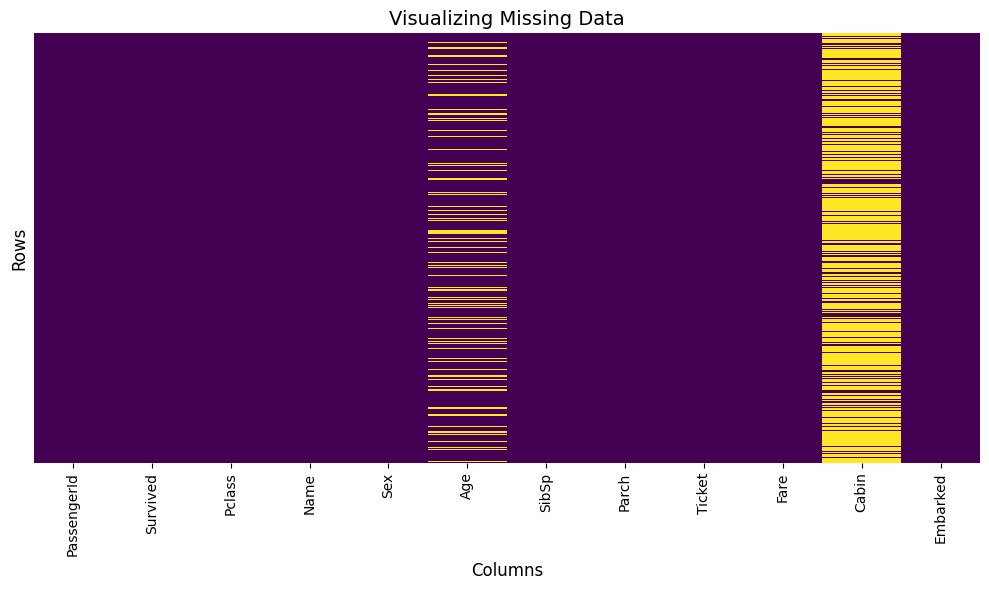

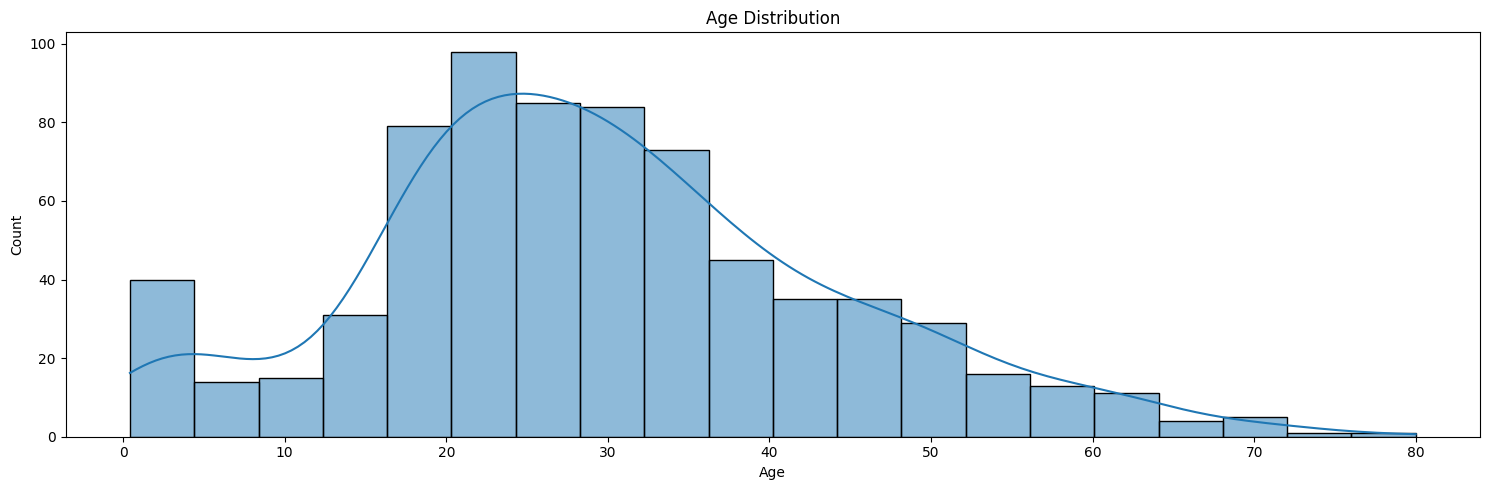

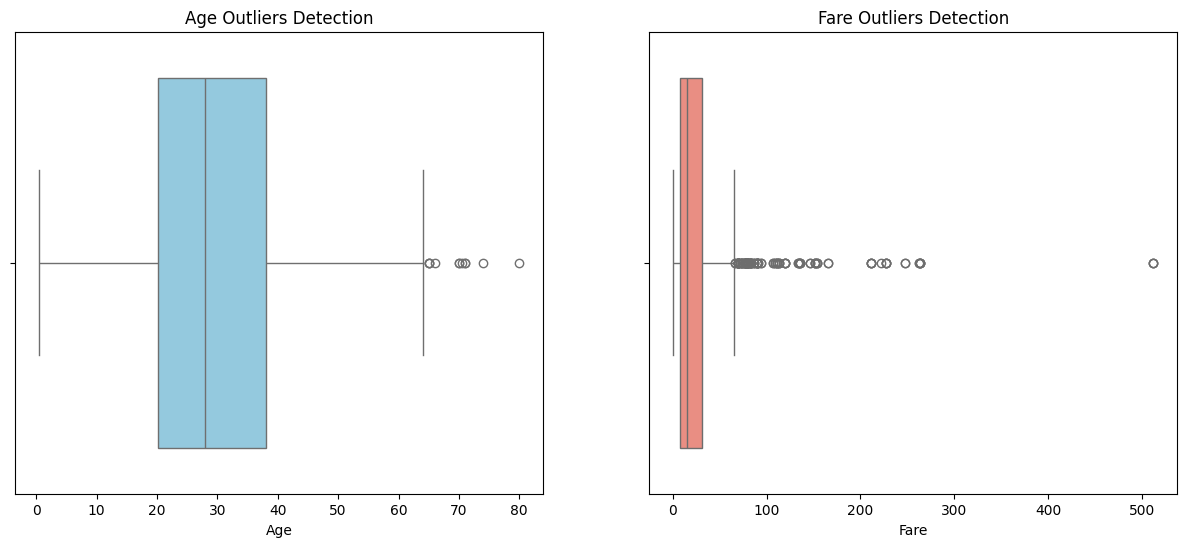

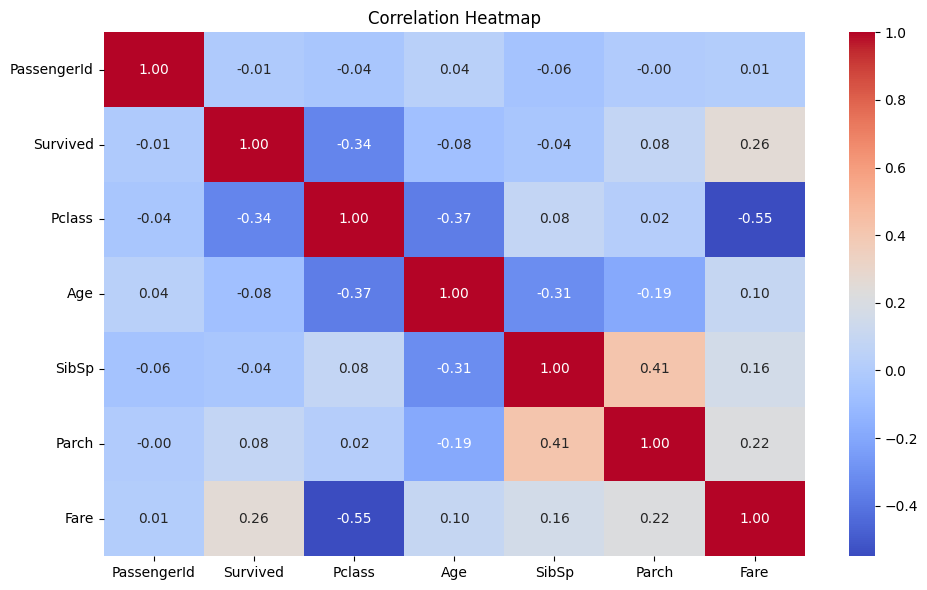

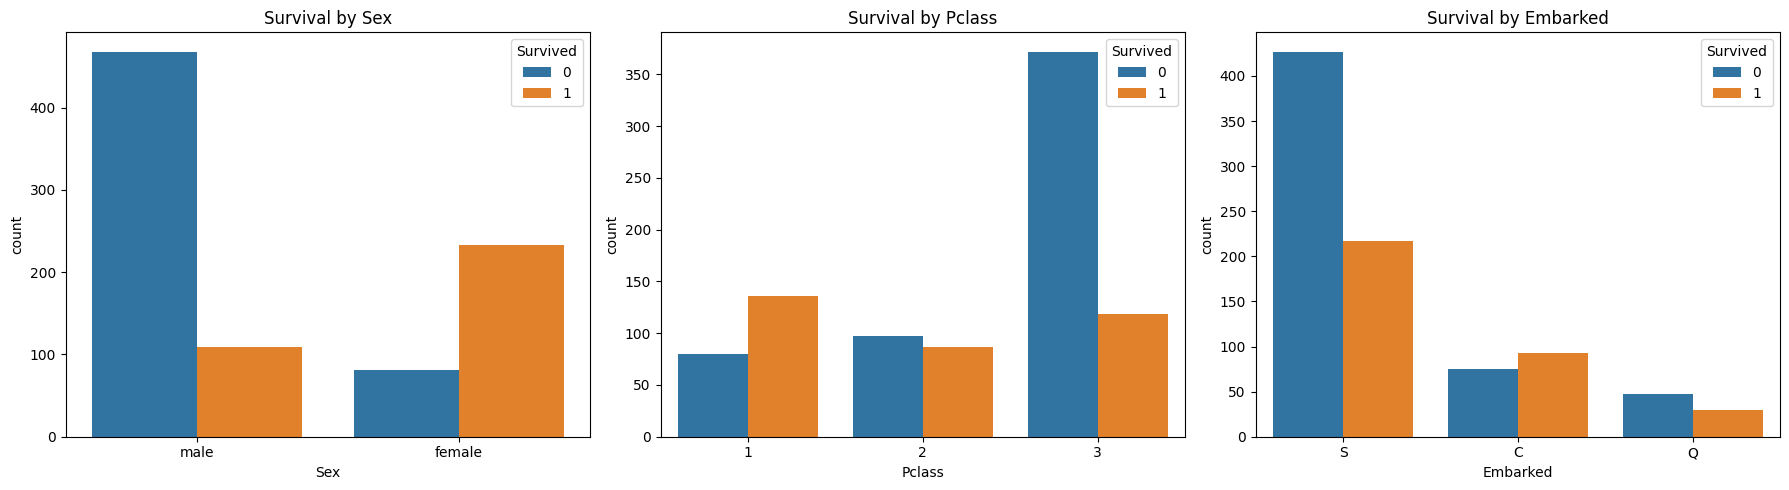

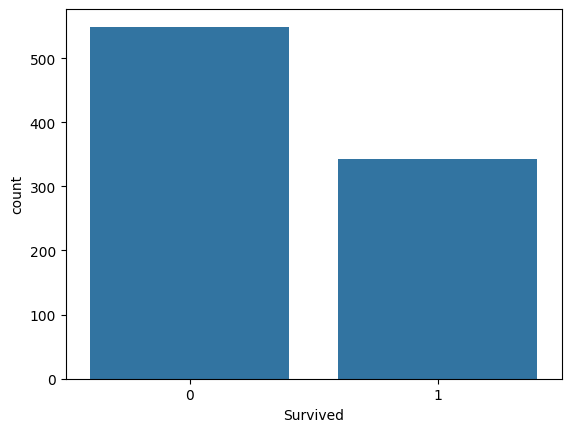

In [4]:
eda(df)

## 3. Data Preprocessing

The preprocessing pipeline is implemented in `Data_Preprocessing.py`.

The preprocessing steps include:

- Text standardization
- Missing value handling
- Outlier handling
- Categorical encoding
- Feature engineering
- Removing unnecessary columns

In [5]:
df_processed = preprocess(df)

df_processed.head()

,Survived,Sex,Age,Fare,Embarked_Q,Embarked_S,Pclass_2,Pclass_3,FamilySize
0,0,0,22.0,7.2500,False,True,False,True,2
1,1,1,38.0,65.6344,False,False,False,False,2
2,1,1,26.0,7.9250,False,True,False,True,1
3,1,1,35.0,53.1000,False,True,False,False,2
4,0,0,35.0,8.0500,False,True,False,True,1


### Preprocessed Dataset

In [6]:
print("Shape after preprocessing:", df_processed.shape)

print("\nColumns:")
print(df_processed.columns)

df_processed.head()

Shape after preprocessing: (891, 9)

Columns:
Index(['Survived', 'Sex', 'Age', 'Fare', 'Embarked_Q', 'Embarked_S',
       'Pclass_2', 'Pclass_3', 'FamilySize'],
      dtype='str')


,Survived,Sex,Age,Fare,Embarked_Q,Embarked_S,Pclass_2,Pclass_3,FamilySize
0,0,0,22.0,7.2500,False,True,False,True,2
1,1,1,38.0,65.6344,False,False,False,False,2
2,1,1,26.0,7.9250,False,True,False,True,1
3,1,1,35.0,53.1000,False,True,False,False,2
4,0,0,35.0,8.0500,False,True,False,True,1


## 4. Preparing Data for Machine Learning

The target variable is `Survived`.

The dataset is divided into:

- Features (`X`)
- Target (`y`)

In [7]:
X, y = separate_target(df_processed, "Survived")

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (891, 8)
Target shape: (891,)


## 5. Machine Learning Models

Five classification algorithms are evaluated:

- Logistic Regression
- Decision Tree
- Random Forest
- Support Vector Classifier (SVC)
- K-Nearest Neighbors (KNN)

Hyperparameter tuning is performed using GridSearchCV with 5-fold cross-validation.

In [8]:
from buildmodels import main
metrics = main()

Best Model: Decision Tree
  Logistic Regression: accuracy=0.806
  Decision Tree: accuracy=0.8209
  Random Forest: accuracy=0.8134
  Svc: accuracy=0.8134
  Knn: accuracy=0.8022


### Model Performance

The models are evaluated using classification accuracy on the test set.

In [9]:
import pandas as pd

results_df = pd.DataFrame(metrics.values())

results_df = results_df.sort_values(
    by='accuracy',
    ascending=False
).reset_index(drop=True)

results_df[['display_name', 'accuracy']]

,display_name,accuracy
0,Decision Tree,0.8209
1,Svc,0.8134
2,Random Forest,0.8134
3,Logistic Regression,0.8060
4,Knn,0.8022


### Model Accuracy Comparison

The following chart compares the test accuracy of the evaluated models.

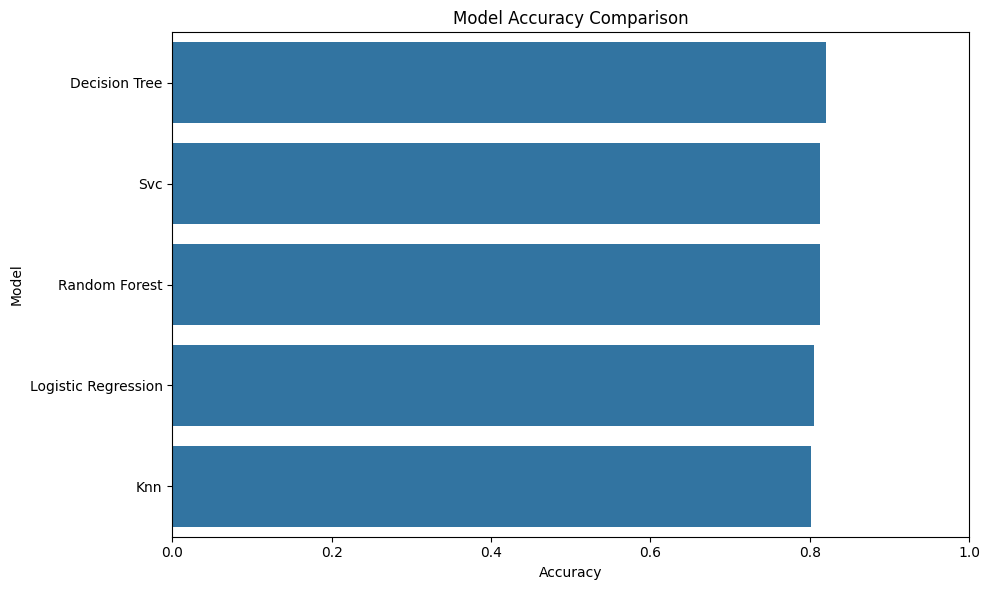

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x='accuracy',
    y='display_name'
)

plt.title('Model Accuracy Comparison')
plt.xlabel('Accuracy')
plt.ylabel('Model')
plt.xlim(0, 1)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

## 6. Best Model

In [11]:
best_model = results_df.iloc[0]

print("Best Model:", best_model['display_name'])
print("Accuracy:", best_model['accuracy'])

Best Model: Decision Tree
Accuracy: 0.8209


## 7. Conclusion

In this project, several Machine Learning classification models were trained and evaluated on the Titanic dataset.

The evaluated models were:

- Logistic Regression
- Decision Tree
- Random Forest
- Support Vector Classifier
- K-Nearest Neighbors

GridSearchCV with 5-fold cross-validation was used to tune the model hyperparameters.

The best-performing model was selected based on its test-set accuracy.

In [12]:
from EDA import FIGURES_DIR

print(FIGURES_DIR)
print(FIGURES_DIR.exists())

D:\Data Science\Data Science Projects\Titanic-Survival-Prediction\results\figures
True
